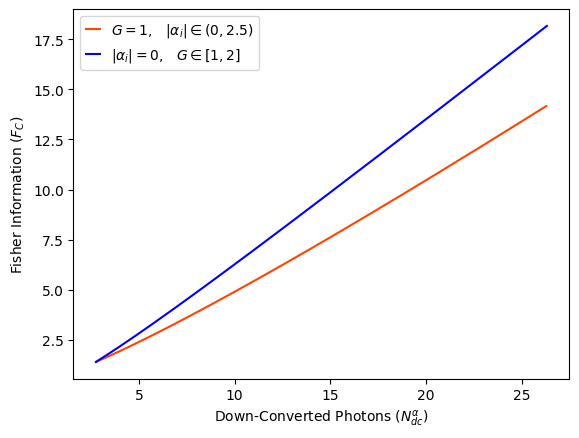

In [ ]:
import numpy as np
from numpy import abs
import matplotlib.pyplot as plt
import sys
from pathlib import Path
# Use __file__ if running as a script, or fallback to the current working directory if in Jupyter
current_dir = Path(__file__).resolve() if '__file__' in locals() else Path.cwd()
# Go up two levels to get the root directory
root_dir = current_dir.parents[1] if '__file__' in locals() else current_dir.parent
# Safely inject the directory to Python's search path
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
from singles import OptimalPhase, OptFisherInfo

#* Variables
G = 1                               #? Gain
T = 0.6                             #? |τ|^2
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(T)                     #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
a_i=np.linspace(0,2.5,500)          #? α_i

F = OptFisherInfo(a_i=a_i, G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 

#* Total Number of down-converted photons: <N_{dc}^{α}>
Ndc=2*abs(np.sinh(G))**2*(1+abs(a_i)**2)+abs(a_i)**2

fig,ax = plt.subplots()
ax.plot(Ndc,F, color="orangered", label=r"$G=1$,   $|\alpha_i|\in(0, 2.5)$")
ax.set_xlabel(r'Down-Converted Photons ($N_{dc}^\alpha$)')
ax.set_ylabel(r"Fisher Information ($F_C$)")

#* Numerical Vectors to consider the case α_i = 0
G_0 = np.linspace(1,2,500)
F_0 = OptFisherInfo(a_i=0, G = G_0, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) 
Ndc_0=2*abs(np.sinh(G_0))**2
ax.plot(Ndc_0, F_0, color="blue",label=r"$|\alpha_i|=0$,   $G\in[1,2]$")

ax.legend(handlelength=1)

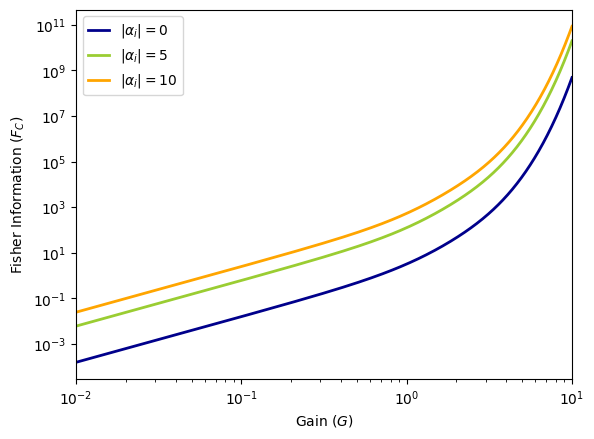

In [6]:
#* Variables
G=np.linspace(1e-2,10,300)          #? Gain
T=0.8                               #? |τ|^2
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(0.8)                   #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
a_i=[0,5,10]                        #? α_i


Ndc_a=[2*abs(np.sinh(G))**2*(1+abs(a_i[j])**2)+abs(a_i[j])**2 for j in range(len(a_i))]
F_a = [OptFisherInfo(a_i=a_i[j], G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) for j in range(len(a_i))]

colors=["darkblue","yellowgreen","orange","deepskyblue","blueviolet"]

fig,ax = plt.subplots()
[ax.plot(G,F_a[j], label=rf"$|\alpha_i|={a_i[j]}$", color= colors[j], linewidth=2) for j in range(len(a_i))]
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim((G.min(),G.max()))
ax.set_xlabel(r"Gain ($G$)")
ax.set_ylabel(r"Fisher Information ($F_C$)")
ax.legend(handlelength=1.5)

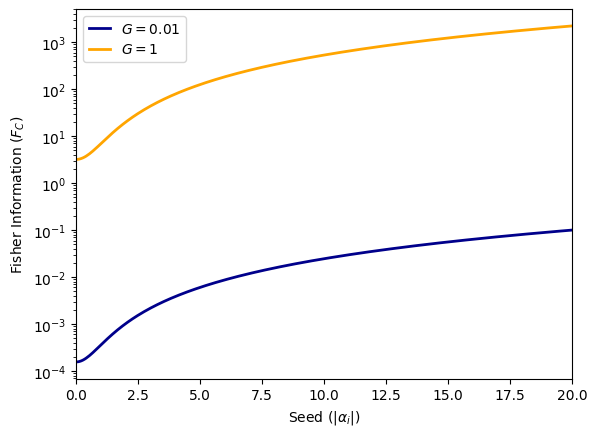

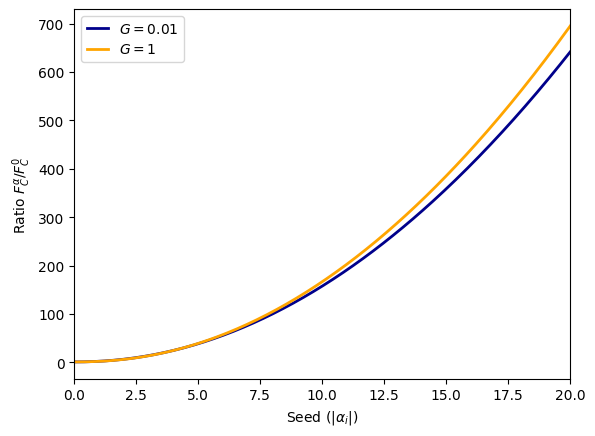

In [5]:
#* Variables
G=[1e-2,1]                          #? Gain
T=0.8                               #? |τ|^2
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(0.8)                   #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
a_i=np.linspace(0,20,300)           #? α_i

F_g = [OptFisherInfo(a_i=a_i, G=G[j], t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) for j in range(len(G))]

colors=["darkblue","orange","deepskyblue","blueviolet"]

fig,ax = plt.subplots()
[ax.plot(a_i,F_g[j], label=rf"$G={G[j]}$", color= colors[j], linewidth=2) for j in range(len(G))]
ax.set_yscale("log")
ax.set_xlim((a_i.min(),a_i.max()))
ax.set_xlabel(r"Seed ($|\alpha_i|$)")
ax.set_ylabel(r"Fisher Information ($F_C$)")
ax.legend(handlelength=1.5)

fig,ax = plt.subplots()
[ax.plot(a_i,F_g[j]/(F_g[j][0]), label=rf"$G={G[j]}$", color= colors[j], linewidth=2) for j in range(len(G))]
ax.set_xlim((a_i.min(),a_i.max()))
ax.set_xlabel(r"Seed ($|\alpha_i|$)")
ax.set_ylabel(r"Ratio $F_C^{\alpha}/F_C^0$")
ax.legend(handlelength=1.5)

#? CONCLUSION: Using a seed with |alpha| improves the sensitivity by more or less the same advantage

[Text(1, 2.356194490192345, '$\\frac{3}{4}\\pi$'),
 Text(1, 3.141592653589793, '$\\pi$')]

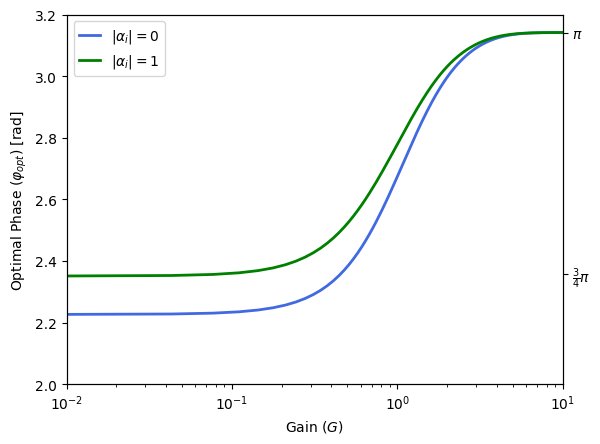

In [7]:
#* Variables
G=np.linspace(1e-2,10,300)          #? Gain
T=0.8                               #? |τ|^2
t_s1=np.sqrt(T)                     #? τ_s1
t_i1=np.sqrt(T)                     #? τ_i1
t_s2=np.sqrt(T)                     #? τ_s2
a_i=[0,1]                           #? α_i

phi_opt=[OptimalPhase(a_i=a_i[j], G=G, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2) for j in range(len(a_i))]

colors=["royalblue", "green"]

fig,ax = plt.subplots()
[ax.plot(G,phi_opt[j], label=rf"$|\alpha_i|={a_i[j]}$", color= colors[j], linewidth=2) for j in range(len(a_i))]
ax.set_xscale("log")
ax.set_xlim((G.min(),G.max()))
ax.set_xlabel(r"Gain ($G$)")
ax.set_ylabel(r"Optimal Phase ($\varphi_{opt}$) [rad]")
ax.legend(handlelength=1.5)
ax.set_ylim((2,3.2))

twinax = ax.twinx() 
twinax.set_ylim(ax.get_ylim())
twinax.set_yticks([3/4*np.pi,np.pi])
twinax.set_yticklabels([r"$\frac{3}{4}\pi$",r"$\pi$"])
